# Map deprivation quantiles in England

Check where the MSOA in each deprivation quantile are located and whether there are any links between deprivation or stroke numbers with rurality or region.

__Method:__

Link the stroke data with rural/urban data and deprivation.

Create maps of the deprivation quantiles and numbers of stroke. 

Calculate the proportions of people in each deprivation band that live in rural areas, are in each age band, or live in each region of England.

__Conclusion:__

The more-deprived MSOA tend to be more urban than the less-deprived areas. Deprivation is spread unequally around England with the north-west contributing more to the more-deprived quantile than the south-east and the reverse for the least-deprived quantile. However there are not clear links between rurality alone or deprivation alone and numbers of stroke.

In [1]:
import os
import numpy as np
import geopandas
import pandas as pd  # for compatability with geopandas
import matplotlib.pyplot as plt
# import cmasher as cmr  # colourmaps

## Load data

Geography data:

In [2]:
msoa_geojson = 'MSOA_Dec_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V3_2022_7707677027087735278.geojson'
path_to_msoa_geojson = os.path.join('..', 'geography_data', 'data_geojson', 'ons_data', msoa_geojson)

In [3]:
gdf_msoa = geopandas.read_file(path_to_msoa_geojson)

In [4]:
gdf_msoa.head()

,OBJECTID,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E02000001,City of London 001,City of London 001,532378,181354,-0.093570,51.51560,a9f03568-7a0a-42b8-a23e-1271f76431e1,"POLYGON ((532946.065 181894.827, 533410.692 18..."
1,2,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,548267,189693,0.138759,51.58659,f0ca54f0-1a1e-4c72-8fcb-85e21be6de79,"POLYGON ((549000.726 190873.464, 549120.966 18..."
2,3,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,548259,188522,0.138150,51.57607,3772a2ec-b052-4000-b62b-2c85ac401a7f,"POLYGON ((548954.517 189063.241, 549085.611 18..."
3,4,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,551004,186418,0.176830,51.55644,3388e1f6-e578-4907-b271-168756f05856,"POLYGON ((551943.782 186027.614, 551670.827 18..."
4,5,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,548733,186827,0.144269,51.56071,1af0aed4-60d0-4fd6-b326-4b868968c12f,"POLYGON ((549418.68 187442.412, 548983.438 186..."


Remove Wales:

In [5]:
mask = gdf_msoa['MSOA11CD'].str.startswith('E')
gdf_msoa = gdf_msoa[mask].copy()

Make outline of England:

In [6]:
gdf_england = gdf_msoa.copy()
gdf_england['dummy'] = 1
gdf_england = gdf_england.dissolve('dummy')

Deprivation quantiles:

In [7]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pd.read_csv(path_to_msoa_stats)

In [8]:
df_stats.head()

,MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,...,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
0,Adur 001,14.333333,16.924833,8815,E,6799,1251,474,0.797630,0.146762,...,0.7872,0.0620,8524,6939.1680,492.7585,465.4320,371.9930,546.5300,0.444,0.556
1,Adur 002,7.333333,6.470400,7263,E,5537,838,259,0.834640,0.126319,...,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.889,1.000
2,Adur 003,9.333333,13.733400,7354,E,5820,969,311,0.819718,0.136479,...,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.556,0.667
3,Adur 004,21.000000,26.199857,10582,E,7872,1546,709,0.777328,0.152661,...,0.8091,0.0638,10127,8561.8962,492.0630,463.4916,388.3594,675.1316,0.222,0.333
4,Adur 005,13.666667,11.794800,9059,E,7106,1081,339,0.833451,0.126789,...,0.7643,0.0662,8526,6923.7937,540.8223,606.9530,385.0075,599.7058,0.667,0.778


In [9]:
df_stats.columns

Index(['MSOA', 'admissions', 'IMD2019Score', 'All persons', 'country',
       'good_health', 'fair health', 'bad health', 'prop_good_health',
       'prop_fair health', 'prop_bad health', 'MSOA11CD', 'age_65_proportion',
       'age_70_proportion', 'age_75_proportion', 'age_less65_proportion',
       'age_over80_proportion', 'total_health', 'age_less65', 'age_65',
       'age_70', 'age_75', 'age_over80', 'depriv_quantile_min',
       'depriv_quantile_max'],
      dtype='object')

Demographics:

In [10]:
msoa_demog = 'collated_data_regional_msoa11cd.csv'
path_to_msoa_geojson = os.path.join('..', 'stroke_unit_demographics', 'data', 'collated_data_by_region', msoa_demog)

In [11]:
df_demog = pd.read_csv(path_to_msoa_geojson)

In [12]:
df_demog.head()

,msoa11cd,polygon_area_km2,population_density,income_domain_weighted_mean,imd_weighted_mean,weighted_ivt_time,mt_time_weighted_mean,ivt_time_weighted_mean,mt_transfer_time_weighted_mean,ethnic_group_other_than_white_british,...,age_90_proportion,rural_False,rural_True,proportion_rural,over_65_within_30_False,over_65_within_30_True,proportion_over_65_within_30,closest_is_mt_False,closest_is_mt_True,proportion_closest_is_mt
0,E02000001,7.4935,1459.6557,0.0693,15.4842,10.9293,10.7663,10.7663,0.0,3132,...,0.0106,10938.0,0.0,0.0,0.0,1731.0,1.0,0.0,10938.0,1.0
1,E02000002,5.6030,1378.9128,0.2165,34.8123,13.3056,13.2008,13.2008,0.0,2861,...,0.0133,7726.0,0.0,0.0,0.0,979.0,1.0,0.0,7726.0,1.0
2,E02000003,5.5425,2029.0451,0.1412,25.2469,10.2465,10.2794,10.2794,0.0,5291,...,0.0068,11246.0,0.0,0.0,0.0,1284.0,1.0,0.0,11246.0,1.0
3,E02000004,6.4333,1033.0652,0.1402,23.8576,9.3787,9.3055,9.3055,0.0,1461,...,0.0169,6646.0,0.0,0.0,0.0,1008.0,1.0,0.0,6646.0,1.0
4,E02000005,3.0652,3438.5836,0.1571,29.6949,10.1000,10.1000,10.1000,0.0,3534,...,0.0052,10540.0,0.0,0.0,0.0,920.0,1.0,0.0,10540.0,1.0


In [13]:
df_demog.columns

Index(['msoa11cd', 'polygon_area_km2', 'population_density',
       'income_domain_weighted_mean', 'imd_weighted_mean', 'weighted_ivt_time',
       'mt_time_weighted_mean', 'ivt_time_weighted_mean',
       'mt_transfer_time_weighted_mean',
       'ethnic_group_other_than_white_british',
       'ethnic_group_all_categories_ethnic_group',
       'ethnic_minority_proportion', 'bad_or_very_bad_health',
       'all_categories_general_health', 'bad_health_proportion',
       'long_term_health_count',
       'all_categories_long_term_health_problem_or_disability',
       'long_term_health_proportion', 'age_65_plus_count', 'population_all',
       'age_65_plus_proportion', 'age_band_all_0', 'age_0_proportion',
       'age_band_all_5', 'age_5_proportion', 'age_band_all_10',
       'age_10_proportion', 'age_band_all_15', 'age_15_proportion',
       'age_band_all_20', 'age_20_proportion', 'age_band_all_25',
       'age_25_proportion', 'age_band_all_30', 'age_30_proportion',
       'age_band_all_3

Regions:

In [14]:
msoa_regions = 'Output_Area_to_LSOA_to_MSOA_to_Local_Authority_District_(December_2017)_Lookup_with_Area_Classifications_in_Great_Britain.csv'
path_to_msoa_regions = os.path.join('..', 'geography_data', 'data_tabular', 'ons_data', msoa_regions)

In [15]:
df_regions = pd.read_csv(path_to_msoa_regions)

In [16]:
df_regions.head()

,OA11CD,OAC11CD,OAC11NM,LSOA11CD,LSOA11NM,SOAC11CD,SOAC11NM,MSOA11CD,MSOA11NM,LAD17CD,LAD17NM,LACCD,LACNM,RGN11CD,RGN11NM,CTRY11CD,CTRY11NM,FID
0,E00060343,7d1,Ageing Communities and Families,E01011966,Hartlepool 006B,5b,Aspiring urban households,E02002488,Hartlepool 006,E06000001,Hartlepool,6a2r,Mining Legacy,E12000001,North East,E92000001,England,1
1,E00174083,7d1,Ageing Communities and Families,E01011974,Hartlepool 005B,4b,Constrained renters,E02002487,Hartlepool 005,E06000001,Hartlepool,6a2r,Mining Legacy,E12000001,North East,E92000001,England,2
2,E00060349,6a4,Ageing in Suburbia,E01011965,Hartlepool 006A,8b,Ageing suburbanites,E02002488,Hartlepool 006,E06000001,Hartlepool,6a2r,Mining Legacy,E12000001,North East,E92000001,England,3
3,E00060418,6a4,Ageing in Suburbia,E01011983,Hartlepool 006C,8a,Affluent communities,E02002488,Hartlepool 006,E06000001,Hartlepool,6a2r,Mining Legacy,E12000001,North East,E92000001,England,4
4,E00060255,8c1,Ageing Industrious Workers,E01011950,Hartlepool 008A,4a,Challenged white communities,E02002490,Hartlepool 008,E06000001,Hartlepool,6a2r,Mining Legacy,E12000001,North East,E92000001,England,5


In [17]:
df_regions.columns

Index(['OA11CD', 'OAC11CD', 'OAC11NM', 'LSOA11CD', 'LSOA11NM', 'SOAC11CD',
       'SOAC11NM', 'MSOA11CD', 'MSOA11NM', 'LAD17CD', 'LAD17NM', 'LACCD',
       'LACNM', 'RGN11CD', 'RGN11NM', 'CTRY11CD', 'CTRY11NM', 'FID'],
      dtype='object')

Combine the sets of data:

In [18]:
df_stats = pd.merge(df_stats, df_regions[['MSOA11CD', 'RGN11NM']].drop_duplicates(), on='MSOA11CD')

In [19]:
df_stats = pd.merge(df_stats, df_demog[['msoa11cd', 'proportion_rural']], left_on='MSOA11CD', right_on='msoa11cd')

In [20]:
gdf_msoa = pd.merge(gdf_msoa, df_stats.drop('MSOA11CD', axis='columns'), left_on='MSOA11NM', right_on='MSOA', how='left')

## Plots

In [21]:
qmin_list = sorted(list(df_stats['depriv_quantile_min'].unique()))
qmax_list = sorted(list(df_stats['depriv_quantile_max'].unique()))

colours = plt.get_cmap('RdYlBu')(np.linspace(0.0, 1.0, len(qmin_list)))

colour_dict = dict(zip(qmin_list, colours))

In [22]:
import matplotlib.patches as mpatches

In [25]:
# labels = ['0-20% (most deprived)', '20-40%', '40-60%', '60-80%', '80-100% (least deprived)']
labels = []
for q, qmin in enumerate(qmin_list):
    label = f'{100.0*qmin:.2f}-{100.0*qmax_list[q]:.2f}%'
    labels.append(label)
labels[0] += ' (most deprived)'
labels[-1] += ' (least deprived)'
legend_labels = dict(zip(qmin_list, labels))

Deprivation level:

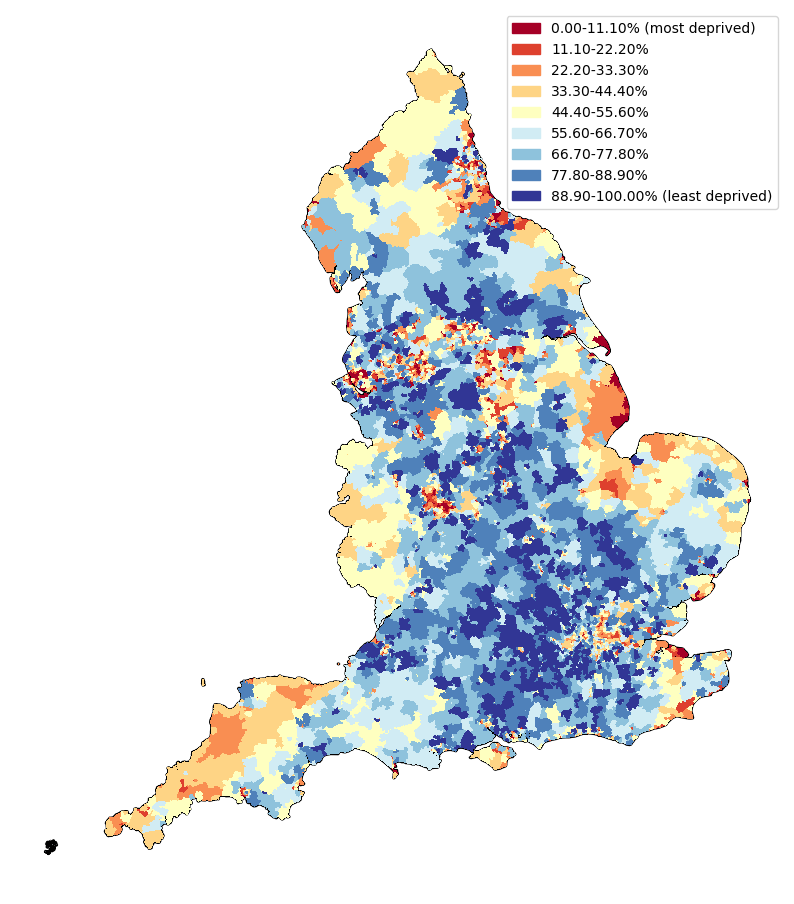

In [42]:
fig, ax = plt.subplots(figsize=(10, 20))

# England outline:
gdf_england.plot(ax=ax, edgecolor='k', linewidth=2)

legend_handles = []
for q in qmin_list:
    gdf_here = gdf_msoa[np.round(gdf_msoa['depriv_quantile_min'], 3) == q]
    gdf_here.plot(
        ax=ax,
        antialiased=False,  # Avoids artefact boundary lines
        facecolor=colour_dict[q],
    )
    legend_handles.append(mpatches.Patch(color=colour_dict[q], label=legend_labels[q]))

ax.legend(handles=legend_handles)
ax.axis('off')
plt.show()

Link this with rural/urban data. Find the proportion of people who live in rural areas, not the proportion of MSOA that are classed as rural, because of slightly differing numbers of people across MSOA.

In [43]:
print('Proportion of people who live in rural areas:')
for q in qmin_list:
    df_here = df_stats[np.round(df_stats['depriv_quantile_min'], 3) == q]
    n_rural = (df_here['proportion_rural'] * df_here['All persons'])
    prop_rural = n_rural.sum() / df_here['All persons'].sum()
    print(f'{legend_labels[q] + ":":25s} {100.0*prop_rural:5.2f}%')

Proportion of people who live in rural areas:
0.00-11.10% (most deprived):  1.53%
11.10-22.20%:              2.82%
22.20-33.30%:              6.64%
33.30-44.40%:             13.85%
44.40-55.60%:             20.12%
55.60-66.70%:             26.99%
66.70-77.80%:             34.13%
77.80-88.90%:             28.18%
88.90-100.00% (least deprived): 20.80%


Definitely seeing the most deprived areas in the most urban areas as a rule.

Check the number of people in each age band with deprivation:

In [44]:
age_cols = ['age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
            'age_75_proportion', 'age_over80_proportion']
print('Percentage of age bands:')

df_age_props = pd.DataFrame()
for q in qmin_list:
    df_here = df_stats[np.round(df_stats['depriv_quantile_min'], 3) == q]
    df_age_props = pd.concat((df_age_props, 100.0 * pd.DataFrame(df_here[age_cols].mean()).transpose()))

df_age_props = np.round(df_age_props, 1)

df_age_props['depriv_quantile_min'] = list(legend_labels.values())
df_age_props = df_age_props.set_index('depriv_quantile_min')

display(df_age_props)

Percentage of age bands:


,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion
depriv_quantile_min,,,,,
0.00-11.10% (most deprived),86.4,4.0,3.6,2.5,3.5
11.10-22.20%,85.4,4.2,3.9,2.7,3.9
22.20-33.30%,83.7,4.5,4.4,3.1,4.4
33.30-44.40%,81.5,5.0,5.0,3.5,5.0
44.40-55.60%,79.5,5.4,5.5,4.0,5.5
55.60-66.70%,78.6,5.6,5.8,4.2,5.8
66.70-77.80%,77.4,5.8,6.2,4.5,6.2
77.80-88.90%,77.6,5.7,6.1,4.4,6.2
88.90-100.00% (least deprived),77.5,5.5,6.1,4.4,6.5


In [45]:
age_cols = ['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']
print('Total people per age bands:')

df_age_props = pd.DataFrame()
for q in qmin_list:
    df_here = df_stats[np.round(df_stats['depriv_quantile_min'], 3) == q]
    df_age_props = pd.concat((df_age_props, pd.DataFrame(df_here[age_cols].sum()).transpose()))

df_age_props['age_over65'] = df_age_props[age_cols[1:]].sum(axis='columns')

df_age_props = np.round(df_age_props, 1)

df_age_props['depriv_quantile_min'] = list(legend_labels.values())
df_age_props = df_age_props.set_index('depriv_quantile_min')

display(df_age_props)

Total people per age bands:


,age_less65,age_65,age_70,age_75,age_over80,age_over65
depriv_quantile_min,,,,,,
0.00-11.10% (most deprived),5412916.1,245218.2,216502.6,148182.3,211245.1,821148.3
11.10-22.20%,5595101.9,262321.2,241403.7,168594.7,241791.3,914110.8
22.20-33.30%,5401464.8,277563.6,265988.5,186458.9,266213.2,996224.2
33.30-44.40%,5161985.2,303373.1,299795.4,213459.6,300696.9,1117325.1
44.40-55.60%,4974393.5,324143.3,331540.4,237287.6,332810.9,1225782.2
55.60-66.70%,4872019.7,334046.1,348581.3,248864.2,349046.1,1280537.7
66.70-77.80%,4702759.4,346292.5,365858.5,264919.7,371198.0,1348268.7
77.80-88.90%,4799591.5,340703.6,364589.1,264880.8,376325.1,1346498.5
88.90-100.00% (least deprived),4675941.5,327523.6,356896.0,260997.3,383580.7,1328997.6


In [46]:
1550475.2 / 2195630.1

0.7061641211786994

The more-deprived quantiles tend to have proportionally more people under 65 and fewer people in all older age bands. This is particularly pronounced for the over-80 age band where the proportion is nearly half as much in the most-deprived areas as it is in the least-deprived.

Total stroke admissions:

In [58]:
print('Total stroke admissions:')
for q in qmin_list:
    df_here = df_stats[np.round(df_stats['depriv_quantile_min'], 3) == q]
    print(f'{legend_labels[q] + ":":31s} {df_here["admissions"].sum():8.2f}')

Total stroke admissions:
0.00-11.10% (most deprived):     9183.00
11.10-22.20%:                    8958.00
22.20-33.30%:                    8962.00
33.30-44.40%:                    9100.33
44.40-55.60%:                    9138.00
55.60-66.70%:                    9235.33
66.70-77.80%:                    9035.00
77.80-88.90%:                    8905.67
88.90-100.00% (least deprived):  8440.67


There isn't a clear link between deprivation alone and number of stroke admissions. Perhaps this is because of a balance between the increase in number of younger people and the increase of chance of stroke for younger people, which would balance out the reduced numbers of older people (even if the probability of stroke for older people were also increased).

Stroke admissions:

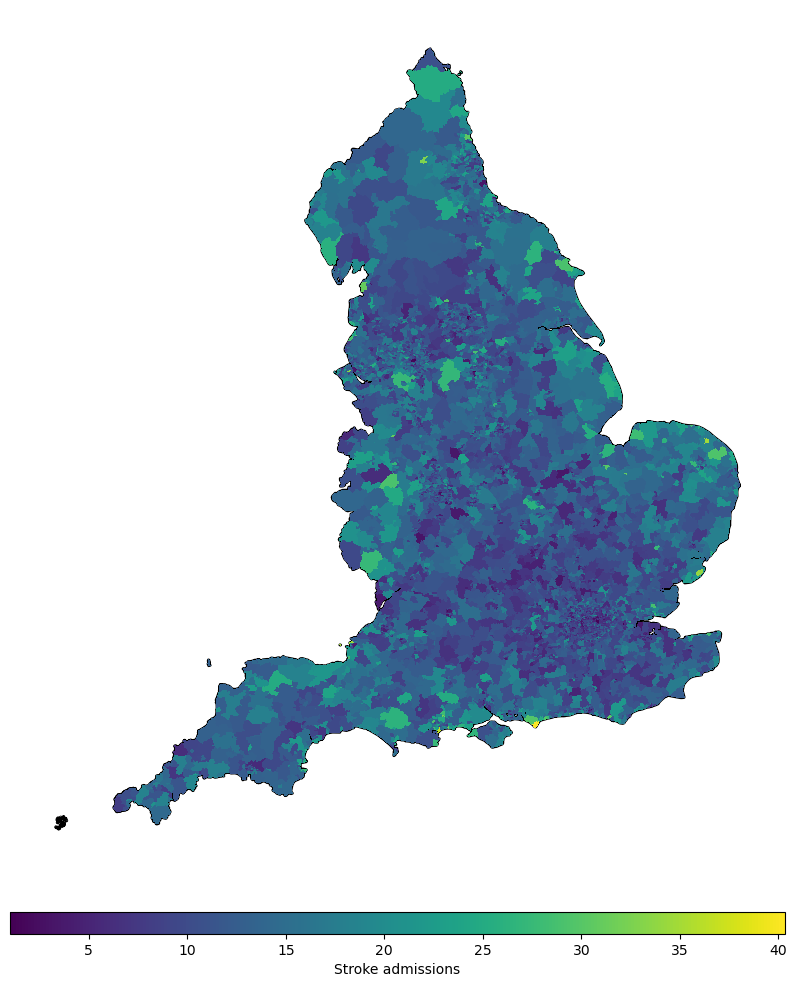

In [48]:
fig, axs = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [40, 1], 'hspace': 0.1})
ax = axs[0]
ax_cbar = axs[1]

# England outline:
gdf_england.plot(ax=ax, edgecolor='k', linewidth=2)

gdf_msoa.plot(
    ax=ax,              # Set which axes to use for plot
    antialiased=False,  # Avoids artefact boundary lines
    column='admissions',  # set colours using this column
    cmap='viridis',
    # edgecolor='face',
    legend=True,  # to draw colourbar
    legend_kwds={'shrink': 0.5, 'label': 'Stroke admissions', 'cax': ax_cbar, 'orientation': 'horizontal'},
)

ax.axis('off')
plt.show()

No clear geographical link for stroke admissions.

Check number of admissions vs proportion of the MSOA that is rural:

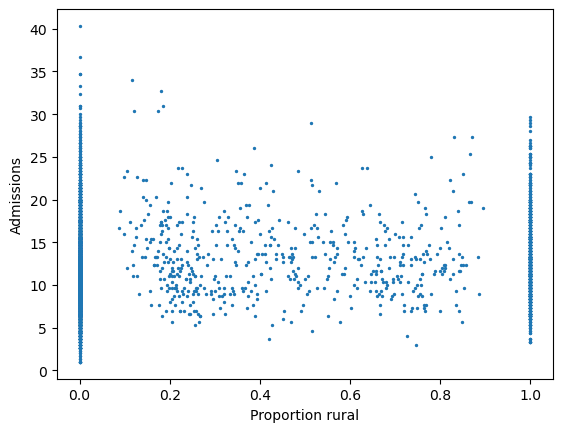

In [49]:
fig, ax = plt.subplots()

ax.scatter(df_stats['proportion_rural'], df_stats['admissions'], s=2)
ax.set_xlabel('Proportion rural')
ax.set_ylabel('Admissions')

plt.show()

No clear link for rural vs admissions. So stick to deprivation for the calculations, leave rurality for discussion and interpretation of the results.

Check number of people in each region by deprivation level:

In [50]:
pd.DataFrame(df_stats['RGN11NM'].value_counts())

,count
RGN11NM,
South East,1108
London,983
North West,924
East of England,736
West Midlands,735
South West,699
Yorkshire and The Humber,692
East Midlands,573
North East,340


In [51]:
pd.DataFrame(df_here)

,MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,...,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max,RGN11NM,msoa11cd,proportion_rural
1,Adur 002,7.333333,6.470400,7263,E,5537,838,259,0.834640,0.126319,...,5423.2821,419.8014,562.1562,357.3396,502.5996,0.889,1.0,South East,E02006535,0.0000
28,Amber Valley 009,17.333333,7.571600,8214,E,6495,847,328,0.846806,0.110430,...,6497.2740,431.2350,501.0540,345.8094,436.1634,0.889,1.0,East Midlands,E02004037,0.0000
34,Amber Valley 016,14.666667,5.869500,8440,E,6523,896,298,0.845277,0.116107,...,6454.9120,422.0000,526.6560,408.4960,628.7800,0.889,1.0,East Midlands,E02004044,0.4109
87,Aylesbury Vale 003,6.666667,7.007000,5853,E,4763,583,185,0.861146,0.105406,...,4475.2038,421.4160,410.8806,244.6554,302.0148,0.889,1.0,South East,E02003654,1.0000
91,Aylesbury Vale 007,10.666667,7.982200,8253,E,5992,788,261,0.851015,0.111916,...,6592.4964,445.6620,468.7704,317.7405,427.5054,0.889,1.0,South East,E02003658,0.6151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6779,York 014,14.333333,6.215250,8251,E,5773,856,243,0.840076,0.124563,...,6686.6104,335.8157,382.8464,273.1081,572.6194,0.889,1.0,Yorkshire and The Humber,E02002785,0.0000
6785,York 020,14.333333,3.259250,6524,E,5441,838,261,0.831957,0.128135,...,4763.1724,388.1780,484.7332,362.0820,525.8344,0.889,1.0,Yorkshire and The Humber,E02002791,1.0000
6786,York 021,12.666667,7.294750,7672,E,6125,700,214,0.870152,0.099446,...,6177.4944,390.5048,349.8432,289.2344,464.9232,0.889,1.0,Yorkshire and The Humber,E02002792,0.0000
6788,York 023,9.000000,6.327667,9542,E,7773,771,273,0.881592,0.087445,...,8238.5628,303.4356,341.6036,262.4050,395.9930,0.889,1.0,Yorkshire and The Humber,E02002794,0.1320


In [52]:
region_cols = sorted(list(df_stats['RGN11NM'].unique()))
print('Number of MSOA in each deprivation level:')

dfs_to_merge = []
for q in qmin_list:
    df_here = df_stats[np.round(df_stats['depriv_quantile_min'], 3) == q]
    df_here = df_here['RGN11NM'].value_counts()
    df_here.name = q
    # df_region_props = pd.concat((df_region_props, 100.0 * pd.DataFrame(df_here[age_cols].mean()).transpose()))
    dfs_to_merge.append(df_here)
    
df_region_counts = pd.concat(dfs_to_merge, axis='columns')
df_region_counts = df_region_counts.sort_index()

df_region_counts_sum = df_region_counts.copy()
df_region_counts_sum['sum'] = df_region_counts_sum.sum(axis='columns')
df_region_counts_sum.loc['sum'] = df_region_counts_sum.sum(axis='rows')

display(df_region_counts_sum)

Number of MSOA in each deprivation level:


,0.0,0.111,0.222,0.333,0.444,0.556,0.667,0.778,0.889,sum
RGN11NM,,,,,,,,,,
East Midlands,51,64,59,53,76,52,71,71,76,573
East of England,23,42,67,77,112,97,98,123,97,736
London,31,169,164,169,112,97,89,89,63,983
North East,79,63,45,37,25,31,18,23,19,340
North West,227,125,107,86,76,80,77,81,65,924
South East,37,54,90,97,107,141,150,166,266,1108
South West,29,46,68,85,100,120,98,90,63,699
West Midlands,134,102,70,90,78,69,83,64,45,735
Yorkshire and The Humber,144,90,83,61,69,67,70,48,60,692


Turn into proportions of region:

In [53]:
cols = qmin_list

df_region_props = df_region_counts.copy()
df_region_props['sum'] = df_region_props.sum(axis='columns')
for c in cols:
    df_region_props[c] /= df_region_props['sum']

In [54]:
np.round(100.0 * df_region_props[cols], 1)

,0.0,0.111,0.222,0.333,0.444,0.556,0.667,0.778,0.889
RGN11NM,,,,,,,,,
East Midlands,8.9,11.2,10.3,9.2,13.3,9.1,12.4,12.4,13.3
East of England,3.1,5.7,9.1,10.5,15.2,13.2,13.3,16.7,13.2
London,3.2,17.2,16.7,17.2,11.4,9.9,9.1,9.1,6.4
North East,23.2,18.5,13.2,10.9,7.4,9.1,5.3,6.8,5.6
North West,24.6,13.5,11.6,9.3,8.2,8.7,8.3,8.8,7.0
South East,3.3,4.9,8.1,8.8,9.7,12.7,13.5,15.0,24.0
South West,4.1,6.6,9.7,12.2,14.3,17.2,14.0,12.9,9.0
West Midlands,18.2,13.9,9.5,12.2,10.6,9.4,11.3,8.7,6.1
Yorkshire and The Humber,20.8,13.0,12.0,8.8,10.0,9.7,10.1,6.9,8.7


Turn into proportions of depriv band:

In [55]:
cols = qmin_list

df_region_deprivs = df_region_counts.copy()
count_sums = df_region_deprivs.sum(axis='rows')
for c, col in enumerate(cols):
    df_region_deprivs[col] /= count_sums[col]
# df_region_deprivs.loc['sum'] = count_sums

In [56]:
np.round(100.0 * df_region_deprivs[cols], 1)

,0.000,0.111,0.222,0.333,0.444,0.556,0.667,0.778,0.889
RGN11NM,,,,,,,,,
East Midlands,6.8,8.5,7.8,7.0,10.1,6.9,9.4,9.4,10.1
East of England,3.0,5.6,8.9,10.2,14.8,12.9,13.0,16.3,12.9
London,4.1,22.4,21.8,22.4,14.8,12.9,11.8,11.8,8.4
North East,10.5,8.3,6.0,4.9,3.3,4.1,2.4,3.0,2.5
North West,30.1,16.6,14.2,11.4,10.1,10.6,10.2,10.7,8.6
South East,4.9,7.2,12.0,12.8,14.2,18.7,19.9,22.0,35.3
South West,3.8,6.1,9.0,11.3,13.2,15.9,13.0,11.9,8.4
West Midlands,17.7,13.5,9.3,11.9,10.3,9.2,11.0,8.5,6.0
Yorkshire and The Humber,19.1,11.9,11.0,8.1,9.1,8.9,9.3,6.4,8.0
